# The Fourier Transform: From Intuition to Computation

The Fourier transform decomposes a signal into its constituent frequencies. This notebook builds up the transform step by step, with visualizations at every stage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

## 1. Signals Are Sums of Sinusoids

Any periodic signal can be expressed as a sum of sine and cosine waves at different frequencies, amplitudes, and phases. Let's see this in action.

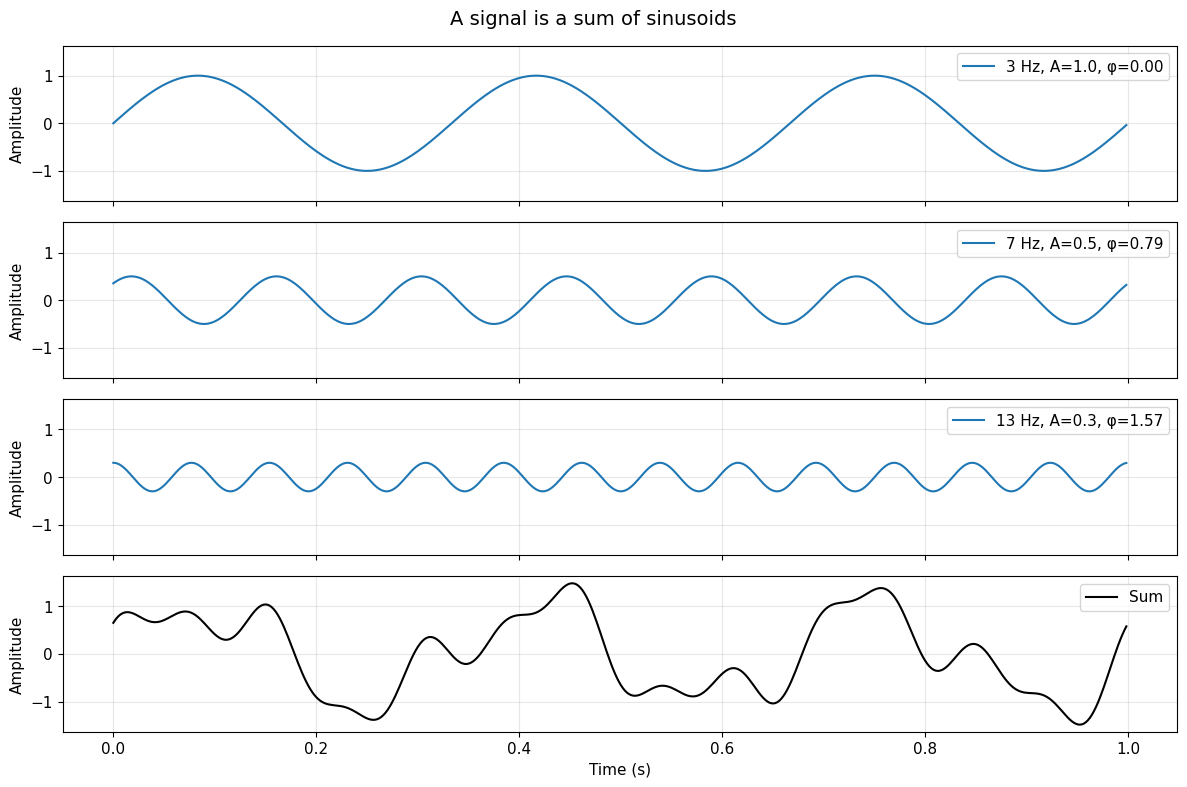

In [2]:
# Time axis: 1 second, sampled at 500 Hz
fs = 500
t = np.linspace(0, 1, fs, endpoint=False)

# Three component sinusoids
components = [
    (3, 1.0, 0),        # 3 Hz, amplitude 1.0, phase 0
    (7, 0.5, np.pi/4),  # 7 Hz, amplitude 0.5, phase pi/4
    (13, 0.3, np.pi/2), # 13 Hz, amplitude 0.3, phase pi/2
]

fig, axes = plt.subplots(len(components) + 1, 1, figsize=(12, 8), sharex=True, sharey=True)

signal = np.zeros_like(t)
for i, (freq, amp, phase) in enumerate(components):
    wave = amp * np.sin(2 * np.pi * freq * t + phase)
    signal += wave
    axes[i].plot(t, wave, label=f'{freq} Hz, A={amp}, φ={phase:.2f}')
    axes[i].legend(loc='upper right')
    axes[i].set_ylabel('Amplitude')

axes[-1].plot(t, signal, color='black', linewidth=1.5, label='Sum')
axes[-1].legend(loc='upper right')
axes[-1].set_ylabel('Amplitude')
axes[-1].set_xlabel('Time (s)')

fig.suptitle('A signal is a sum of sinusoids', fontsize=14)
plt.tight_layout()
plt.show()

## 2. The Core Idea: Correlation with Complex Exponentials

The Fourier transform asks: **"How much of frequency $f$ is in my signal?"**

To answer this, we multiply the signal by $e^{-i 2\pi f t}$ and integrate (or sum, for discrete signals). But what does $e^{i\theta}$ even mean when the exponent is imaginary? The answer comes from **Euler's formula**:

$$e^{i\theta} = \cos\theta + i\sin\theta$$

### Deriving Euler's formula from Taylor series

Recall the Taylor series for the three functions involved:

$$e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \frac{x^4}{4!} + \frac{x^5}{5!} + \cdots$$

$$\cos\theta = 1 - \frac{\theta^2}{2!} + \frac{\theta^4}{4!} - \frac{\theta^6}{6!} + \cdots$$

$$\sin\theta = \theta - \frac{\theta^3}{3!} + \frac{\theta^5}{5!} - \frac{\theta^7}{7!} + \cdots$$

Now substitute $x = i\theta$ into the exponential series, using the fact that $i^2 = -1$, $i^3 = -i$, $i^4 = 1$, $i^5 = i$, and so on:

$$e^{i\theta} = 1 + i\theta + \frac{(i\theta)^2}{2!} + \frac{(i\theta)^3}{3!} + \frac{(i\theta)^4}{4!} + \frac{(i\theta)^5}{5!} + \cdots$$

$$= 1 + i\theta - \frac{\theta^2}{2!} - \frac{i\theta^3}{3!} + \frac{\theta^4}{4!} + \frac{i\theta^5}{5!} - \cdots$$

Group the real and imaginary parts:

$$= \underbrace{\left(1 - \frac{\theta^2}{2!} + \frac{\theta^4}{4!} - \cdots\right)}_{\cos\theta} + \; i\underbrace{\left(\theta - \frac{\theta^3}{3!} + \frac{\theta^5}{5!} - \cdots\right)}_{\sin\theta}$$

$$\boxed{e^{i\theta} = \cos\theta + i\sin\theta}$$

Therefore, with $\theta = -2\pi f t$:

$$e^{-i 2\pi f t} = \cos(2\pi f t) - i\sin(2\pi f t)$$

This means multiplying by $e^{-i2\pi ft}$ simultaneously correlates the signal against a cosine (real part) and a negative sine (imaginary part) at frequency $f$. When the signal contains that frequency, these correlations are large; when it doesn't, they cancel out.

Let's visualize this "correlation" process for a probe frequency that matches vs. one that doesn't.

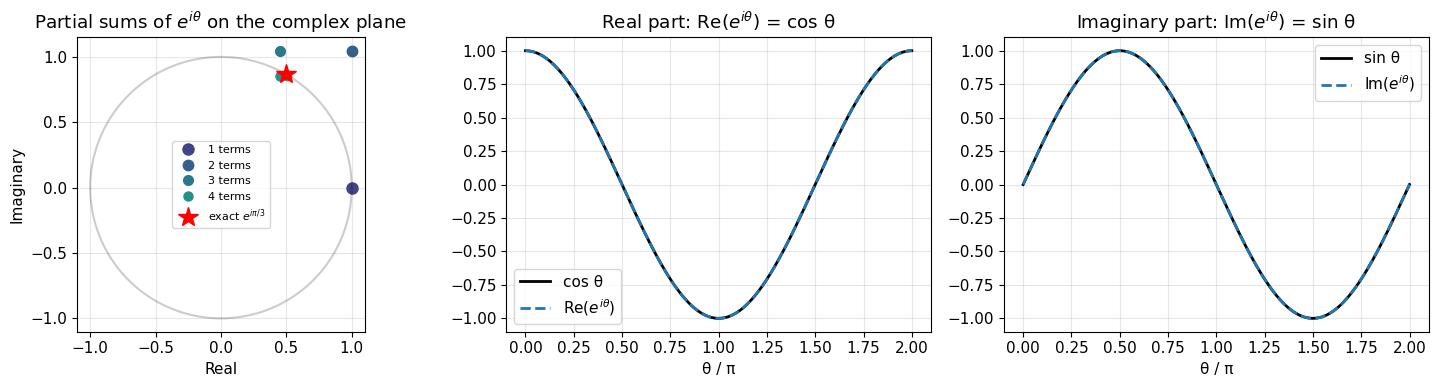

θ/π        e^(iθ)                         cos θ + i sin θ              match?
-------------------------------------------------------------------------------------
 0.00π    +1.00000 +0.00000i          +1.00000 +0.00000i          True
 0.17π    +0.86603 +0.50000i          +0.86603 +0.50000i          True
 0.25π    +0.70711 +0.70711i          +0.70711 +0.70711i          True
 0.33π    +0.50000 +0.86603i          +0.50000 +0.86603i          True
 0.50π    +0.00000 +1.00000i          +0.00000 +1.00000i          True
 1.00π    -1.00000 +0.00000i          -1.00000 +0.00000i          True


In [3]:
# Verify Euler's formula: compare Taylor series partial sums with cos + i*sin
from math import factorial

theta = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: show partial sums of e^(iθ) converging on the unit circle
ax = axes[0]
ax.set_aspect('equal')
ax.set_title("Partial sums of $e^{i\\theta}$ on the complex plane")
theta_demo = np.pi / 3  # pick one angle to illustrate
partial = 0 + 0j
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 8))
for n in range(8):
    partial += (1j * theta_demo) ** n / factorial(n)
    ax.plot(partial.real, partial.imag, 'o', color=colors[n], markersize=8 - n * 0.5,
            label=f'{n+1} terms' if n < 4 else None)
# Draw unit circle
circle = np.exp(1j * np.linspace(0, 2 * np.pi, 200))
ax.plot(circle.real, circle.imag, 'k-', alpha=0.2)
# Mark the exact answer
exact = np.exp(1j * theta_demo)
ax.plot(exact.real, exact.imag, 'r*', markersize=15, label=f'exact $e^{{i\\pi/3}}$')
ax.legend(fontsize=8)
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')

# Middle: real part = cos(θ)
axes[1].plot(theta / np.pi, np.cos(theta), 'k-', linewidth=2, label='cos θ')
axes[1].plot(theta / np.pi, np.exp(1j * theta).real, '--', linewidth=2, label='Re($e^{iθ}$)')
axes[1].set_title('Real part: Re($e^{i\\theta}$) = cos θ')
axes[1].set_xlabel('θ / π')
axes[1].legend()

# Right: imaginary part = sin(θ)
axes[2].plot(theta / np.pi, np.sin(theta), 'k-', linewidth=2, label='sin θ')
axes[2].plot(theta / np.pi, np.exp(1j * theta).imag, '--', linewidth=2, label='Im($e^{iθ}$)')
axes[2].set_title('Imaginary part: Im($e^{i\\theta}$) = sin θ')
axes[2].set_xlabel('θ / π')
axes[2].legend()

plt.tight_layout()
plt.show()

# Numerical check
theta_test = np.array([0, np.pi/6, np.pi/4, np.pi/3, np.pi/2, np.pi])
print("θ/π        e^(iθ)                         cos θ + i sin θ              match?")
print("-" * 85)
for th in theta_test:
    lhs = np.exp(1j * th)
    rhs = np.cos(th) + 1j * np.sin(th)
    print(f"{th/np.pi:5.2f}π    {lhs.real:+8.5f} {lhs.imag:+8.5f}i"
          f"          {rhs.real:+8.5f} {rhs.imag:+8.5f}i"
          f"          {np.isclose(lhs, rhs)}")

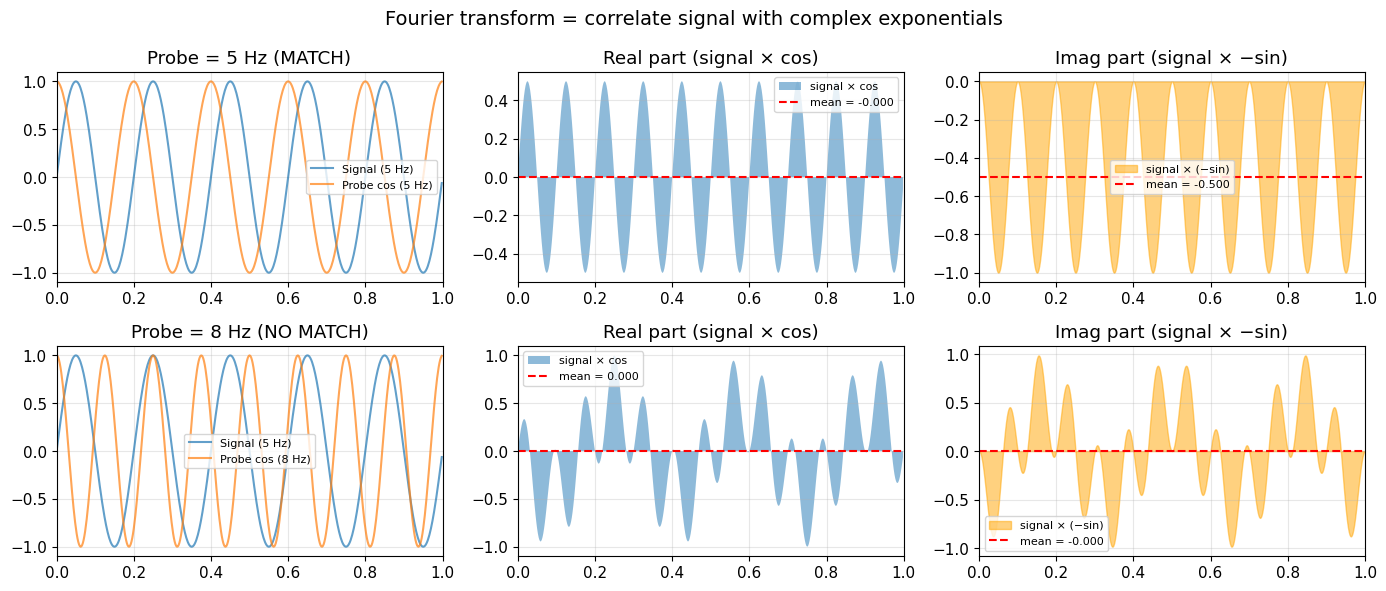

In [4]:
# Simple test signal: pure 5 Hz sine
test_signal = np.sin(2 * np.pi * 5 * t)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for row, probe_freq in enumerate([5, 8]):
    # The probe: cos and -sin at the probe frequency
    probe_cos = np.cos(2 * np.pi * probe_freq * t)
    probe_sin = -np.sin(2 * np.pi * probe_freq * t)

    # Products
    prod_cos = test_signal * probe_cos
    prod_sin = test_signal * probe_sin

    match = "MATCH" if probe_freq == 5 else "NO MATCH"

    axes[row, 0].plot(t, test_signal, alpha=0.7, label='Signal (5 Hz)')
    axes[row, 0].plot(t, probe_cos, alpha=0.7, label=f'Probe cos ({probe_freq} Hz)')
    axes[row, 0].set_title(f'Probe = {probe_freq} Hz ({match})')
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].fill_between(t, prod_cos, alpha=0.5, label='signal × cos')
    axes[row, 1].axhline(y=np.mean(prod_cos), color='red', linestyle='--',
                          label=f'mean = {np.mean(prod_cos):.3f}')
    axes[row, 1].set_title('Real part (signal × cos)')
    axes[row, 1].legend(fontsize=8)

    axes[row, 2].fill_between(t, prod_sin, alpha=0.5, color='orange', label='signal × (−sin)')
    axes[row, 2].axhline(y=np.mean(prod_sin), color='red', linestyle='--',
                          label=f'mean = {np.mean(prod_sin):.3f}')
    axes[row, 2].set_title('Imag part (signal × −sin)')
    axes[row, 2].legend(fontsize=8)

for ax in axes.flat:
    ax.set_xlim(0, 1)

fig.suptitle('Fourier transform = correlate signal with complex exponentials', fontsize=14)
plt.tight_layout()
plt.show()

When the probe frequency **matches** (5 Hz), the product has a consistent positive bias — the mean is large. When it **doesn't match** (8 Hz), the product oscillates symmetrically — the mean is near zero. That's the entire mechanism.

## 3. The Discrete Fourier Transform (DFT)

For $N$ samples, the DFT is:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-i 2\pi k n / N}$$

where $k$ indexes the frequency bin. Let's implement it from scratch and compare with NumPy's FFT.

Max difference between our DFT and np.fft.fft: 3.85e-13


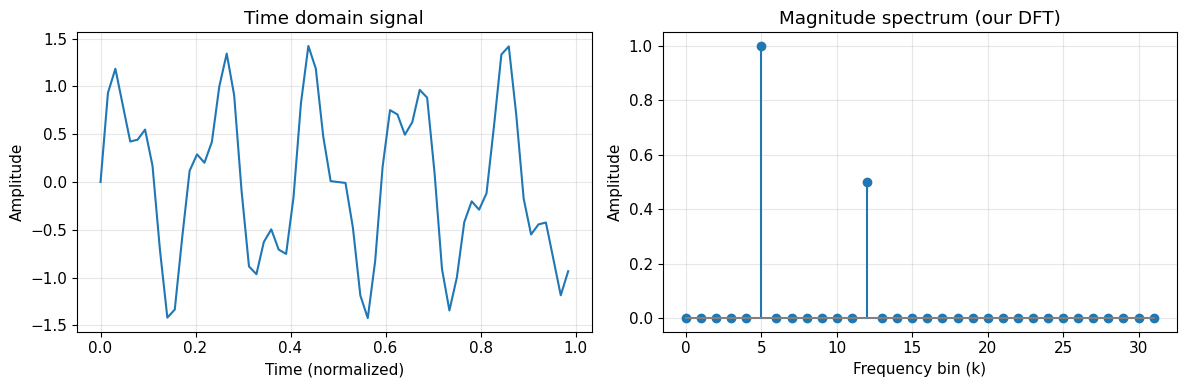

In [5]:
def dft(x):
    """Compute the Discrete Fourier Transform from the definition."""
    N = len(x)
    n = np.arange(N)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        X[k] = np.sum(x * np.exp(-2j * np.pi * k * n / N))
    return X


# Use a short signal so our naive DFT is fast
N = 64
t_short = np.arange(N) / N
x = np.sin(2 * np.pi * 5 * t_short) + 0.5 * np.sin(2 * np.pi * 12 * t_short)

X_ours = dft(x)
X_numpy = np.fft.fft(x)

print(f"Max difference between our DFT and np.fft.fft: {np.max(np.abs(X_ours - X_numpy)):.2e}")

# Plot magnitude spectrum
freqs = np.arange(N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_short, x)
axes[0].set_title('Time domain signal')
axes[0].set_xlabel('Time (normalized)')
axes[0].set_ylabel('Amplitude')

axes[1].stem(freqs[:N//2], np.abs(X_ours[:N//2]) / N * 2, markerfmt='o', basefmt='gray')
axes[1].set_title('Magnitude spectrum (our DFT)')
axes[1].set_xlabel('Frequency bin (k)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

The peaks at bins 5 and 12 correspond exactly to our input frequencies. The magnitudes (after normalization) recover the original amplitudes: 1.0 and 0.5.

## 4. Magnitude and Phase

Each DFT coefficient $X[k]$ is a complex number. Its **magnitude** tells us how much of that frequency is present; its **phase** tells us where the wave is shifted.

$$|X[k]| = \sqrt{\text{Re}(X[k])^2 + \text{Im}(X[k])^2}, \qquad \angle X[k] = \text{atan2}(\text{Im}(X[k]),\, \text{Re}(X[k]))$$

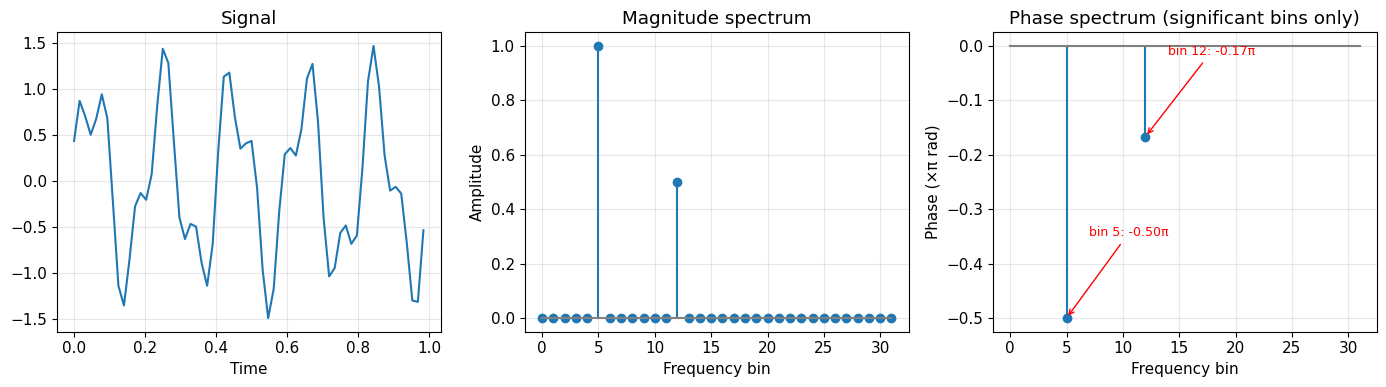

Phase at bin 5: -1.5708 rad = -0.5000π
Phase at bin 12: -0.5236 rad = -0.1667π

Note: sin(x) = cos(x − π/2), so a sin with phase φ appears in the DFT
with phase φ − π/2. For bin 5: 0 − π/2 = −π/2. For bin 12: π/3 − π/2 = −π/6.


In [6]:
# Signal with known phases
x_phased = (
    1.0 * np.sin(2 * np.pi * 5 * t_short + 0) +         # phase = 0
    0.5 * np.sin(2 * np.pi * 12 * t_short + np.pi / 3)   # phase = π/3
)

X_p = np.fft.fft(x_phased)
magnitudes = np.abs(X_p) / N * 2
phases = np.angle(X_p)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t_short, x_phased)
axes[0].set_title('Signal')
axes[0].set_xlabel('Time')

axes[1].stem(freqs[:N//2], magnitudes[:N//2], markerfmt='o', basefmt='gray')
axes[1].set_title('Magnitude spectrum')
axes[1].set_xlabel('Frequency bin')
axes[1].set_ylabel('Amplitude')

# Only show phase where magnitude is significant
phase_display = np.where(magnitudes[:N//2] > 0.05, phases[:N//2], np.nan)
axes[2].stem(freqs[:N//2], phase_display / np.pi, markerfmt='o', basefmt='gray')
axes[2].set_title('Phase spectrum (significant bins only)')
axes[2].set_xlabel('Frequency bin')
axes[2].set_ylabel('Phase (×π rad)')

# Annotate the phase values
for k in [5, 12]:
    # sin(ωt + φ) has DFT phase = φ - π/2 (because sin = cos shifted by -π/2)
    axes[2].annotate(f'bin {k}: {phases[k]/np.pi:.2f}π',
                     xy=(k, phases[k]/np.pi), fontsize=9,
                     xytext=(k+2, phases[k]/np.pi + 0.15),
                     arrowprops=dict(arrowstyle='->', color='red'),
                     color='red')

plt.tight_layout()
plt.show()

print("Phase at bin 5:", f"{phases[5]:.4f} rad = {phases[5]/np.pi:.4f}π")
print("Phase at bin 12:", f"{phases[12]:.4f} rad = {phases[12]/np.pi:.4f}π")
print()
print("Note: sin(x) = cos(x − π/2), so a sin with phase φ appears in the DFT")
print("with phase φ − π/2. For bin 5: 0 − π/2 = −π/2. For bin 12: π/3 − π/2 = −π/6.")

## 5. The Inverse DFT: Perfect Reconstruction

The inverse DFT reconstructs the original signal from its frequency components:

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \cdot e^{i 2\pi k n / N}$$

The only differences from the forward DFT: the sign in the exponent flips, and we divide by $N$.

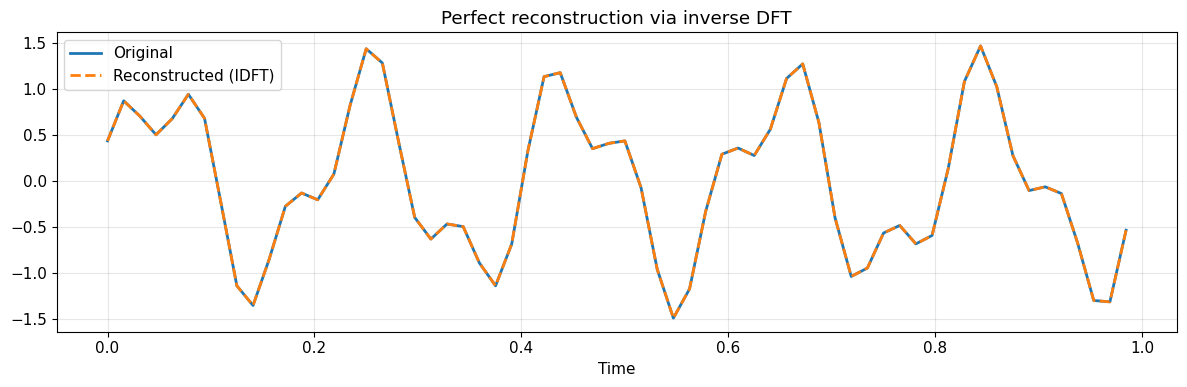

Max reconstruction error: 2.75e-14


In [7]:
def idft(X):
    """Compute the Inverse DFT from the definition."""
    N = len(X)
    k = np.arange(N)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        x[n] = np.sum(X * np.exp(2j * np.pi * k * n / N)) / N
    return x


x_reconstructed = idft(X_p).real

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_short, x_phased, label='Original', linewidth=2)
ax.plot(t_short, x_reconstructed, '--', label='Reconstructed (IDFT)', linewidth=2)
ax.set_title('Perfect reconstruction via inverse DFT')
ax.set_xlabel('Time')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Max reconstruction error: {np.max(np.abs(x_phased - x_reconstructed)):.2e}")

## 6. Key Properties of the Fourier Transform

### 6a. Linearity

$$\mathcal{F}\{a \cdot x + b \cdot y\} = a \cdot \mathcal{F}\{x\} + b \cdot \mathcal{F}\{y\}$$

The transform of a sum equals the sum of the transforms.

Linearity check — max difference: 1.42e-14


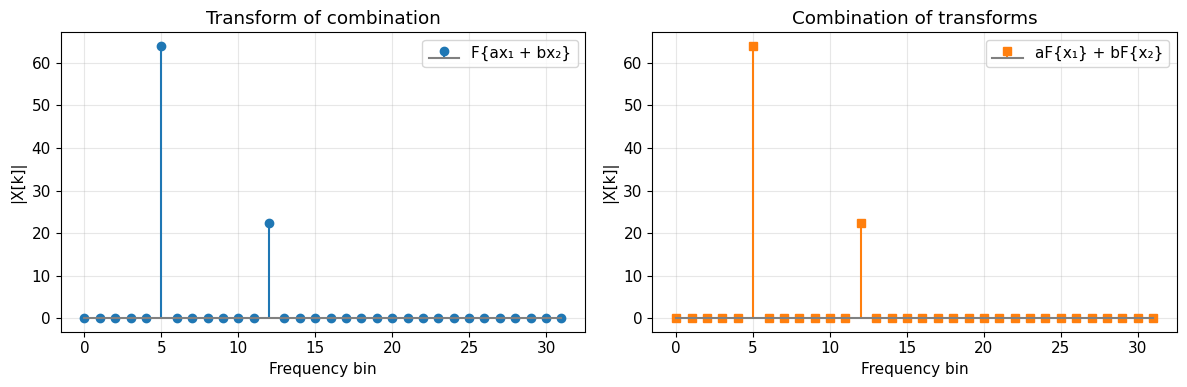

In [8]:
x1 = np.sin(2 * np.pi * 5 * t_short)
x2 = np.cos(2 * np.pi * 12 * t_short)
a, b = 2.0, 0.7

# Transform of the combination
F_combined = np.fft.fft(a * x1 + b * x2)

# Combination of the transforms
combined_F = a * np.fft.fft(x1) + b * np.fft.fft(x2)

print(f"Linearity check — max difference: {np.max(np.abs(F_combined - combined_F)):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(freqs[:N//2], np.abs(F_combined[:N//2]), markerfmt='o', basefmt='gray',
             label='F{ax₁ + bx₂}')
axes[0].set_title('Transform of combination')
axes[0].legend()

axes[1].stem(freqs[:N//2], np.abs(combined_F[:N//2]), markerfmt='s', basefmt='gray',
             linefmt='C1-', label='aF{x₁} + bF{x₂}')
axes[1].set_title('Combination of transforms')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Frequency bin')
    ax.set_ylabel('|X[k]|')

plt.tight_layout()
plt.show()

### 6b. Time Shift → Phase Shift

Shifting a signal in time multiplies its spectrum by a complex exponential (changing phase, not magnitude):

$$\mathcal{F}\{x[n - n_0]\} = e^{-i 2\pi k n_0 / N} \cdot X[k]$$

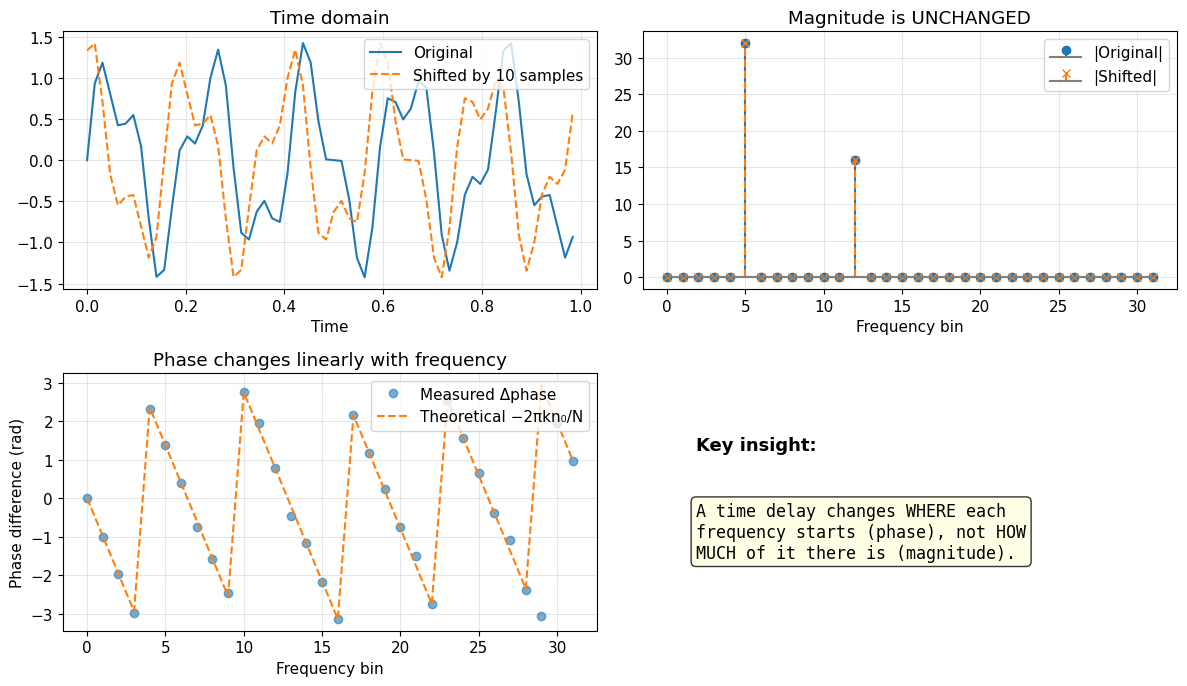

In [9]:
shift = 10  # shift by 10 samples
x_shifted = np.roll(x, shift)

X_orig = np.fft.fft(x)
X_shifted = np.fft.fft(x_shifted)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(t_short, x, label='Original')
axes[0, 0].plot(t_short, x_shifted, '--', label=f'Shifted by {shift} samples')
axes[0, 0].set_title('Time domain')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Time')

axes[0, 1].stem(freqs[:N//2], np.abs(X_orig[:N//2]), markerfmt='o', basefmt='gray',
                label='|Original|')
axes[0, 1].stem(freqs[:N//2], np.abs(X_shifted[:N//2]), markerfmt='x', basefmt='gray',
                linefmt='C1--', label='|Shifted|')
axes[0, 1].set_title('Magnitude is UNCHANGED')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Frequency bin')

# Phase difference
sig_bins = np.abs(X_orig) > 1  # only look at significant bins
phase_diff = np.angle(X_shifted) - np.angle(X_orig)
# Wrap to [-π, π]
phase_diff = (phase_diff + np.pi) % (2 * np.pi) - np.pi

# Theoretical phase shift
theoretical_phase = -2 * np.pi * freqs * shift / N
theoretical_phase = (theoretical_phase + np.pi) % (2 * np.pi) - np.pi

axes[1, 0].plot(freqs[:N//2], phase_diff[:N//2], 'o', label='Measured Δphase', alpha=0.6)
axes[1, 0].plot(freqs[:N//2], theoretical_phase[:N//2], '--', label='Theoretical −2πkn₀/N')
axes[1, 0].set_title('Phase changes linearly with frequency')
axes[1, 0].set_xlabel('Frequency bin')
axes[1, 0].set_ylabel('Phase difference (rad)')
axes[1, 0].legend()

# Verify at significant bins
axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.7, 'Key insight:', fontsize=13, fontweight='bold',
                transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.5,
    'A time delay changes WHERE each\n'
    'frequency starts (phase), not HOW\n'
    'MUCH of it there is (magnitude).',
    fontsize=12, transform=axes[1, 1].transAxes,
    verticalalignment='top', family='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

### 6c. Parseval's Theorem (Energy Conservation)

The total energy is the same whether computed in the time domain or the frequency domain:

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

In [10]:
energy_time = np.sum(np.abs(x) ** 2)
energy_freq = np.sum(np.abs(X_orig) ** 2) / N

print(f"Energy in time domain:  {energy_time:.6f}")
print(f"Energy in freq domain:  {energy_freq:.6f}")
print(f"Ratio (should be 1.0): {energy_time / energy_freq:.10f}")

Energy in time domain:  40.000000
Energy in freq domain:  40.000000
Ratio (should be 1.0): 1.0000000000


### 6d. Convolution Theorem

Convolution in the time domain is multiplication in the frequency domain (and vice versa):

$$\mathcal{F}\{x * h\} = X \cdot H$$

This is why FFT-based convolution is so efficient: instead of $O(N^2)$ multiplications, we do two FFTs + pointwise multiply + one IFFT = $O(N \log N)$.

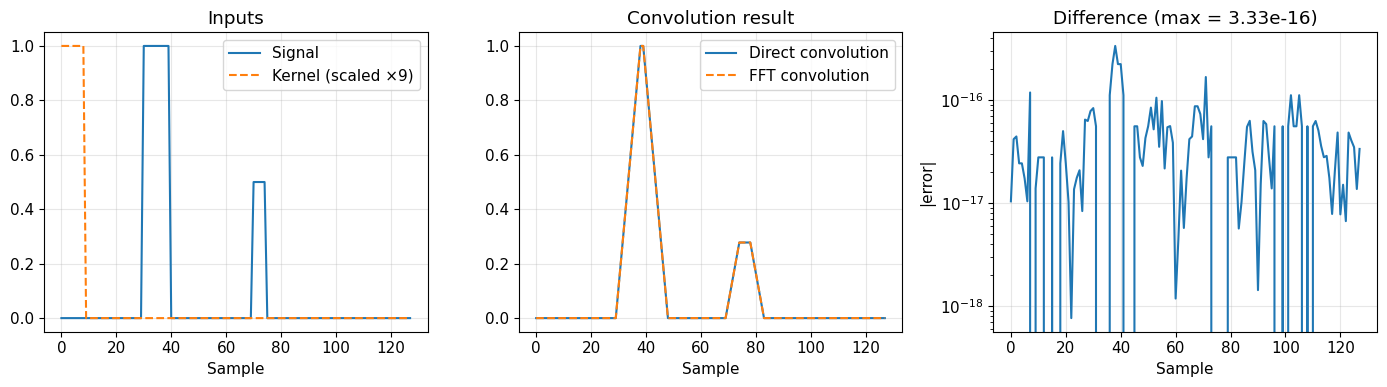

In [11]:
# Create a signal and a filter kernel
N_conv = 128
t_conv = np.arange(N_conv) / N_conv

signal_conv = np.zeros(N_conv)
signal_conv[30:40] = 1.0   # rectangular pulse
signal_conv[70:75] = 0.5   # shorter pulse

# Simple averaging (smoothing) kernel
kernel = np.zeros(N_conv)
kernel[:9] = 1.0 / 9  # 9-point moving average

# Method 1: Direct circular convolution
conv_direct = np.real(np.fft.ifft(np.fft.fft(signal_conv) * np.fft.fft(kernel)))

# Method 2: np.convolve (linear, for comparison we wrap it)
# Circular convolution via definition
conv_circular = np.zeros(N_conv)
for n in range(N_conv):
    for m in range(N_conv):
        conv_circular[n] += signal_conv[m] * kernel[(n - m) % N_conv]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(signal_conv, label='Signal')
axes[0].plot(kernel * 9, '--', label='Kernel (scaled ×9)')  # scale for visibility
axes[0].set_title('Inputs')
axes[0].legend()

axes[1].plot(conv_circular, label='Direct convolution')
axes[1].plot(conv_direct, '--', label='FFT convolution')
axes[1].set_title('Convolution result')
axes[1].legend()

axes[2].semilogy(np.abs(conv_circular - conv_direct))
axes[2].set_title(f'Difference (max = {np.max(np.abs(conv_circular - conv_direct)):.2e})')
axes[2].set_ylabel('|error|')

for ax in axes:
    ax.set_xlabel('Sample')

plt.tight_layout()
plt.show()

## 7. Spectral Leakage and Windowing

When a signal's frequency doesn't land exactly on a DFT bin, energy "leaks" into neighboring bins. **Windowing** reduces this leakage by tapering the signal at the edges.

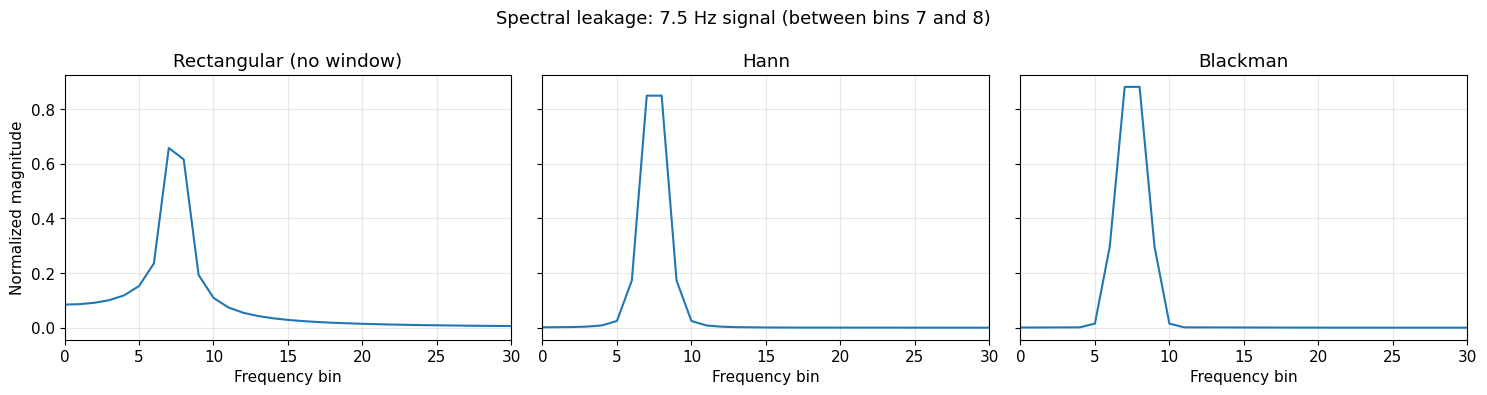

In [12]:
N_leak = 256
t_leak = np.arange(N_leak) / N_leak

# 7.5 Hz: falls exactly between bins 7 and 8 → leakage
x_leak = np.sin(2 * np.pi * 7.5 * t_leak)

# Apply windows
windows = {
    'Rectangular (no window)': np.ones(N_leak),
    'Hann': np.hanning(N_leak),
    'Blackman': np.blackman(N_leak),
}

fig, axes = plt.subplots(1, len(windows), figsize=(15, 4), sharey=True)

for ax, (name, window) in zip(axes, windows.items()):
    X_w = np.fft.fft(x_leak * window)
    mag = np.abs(X_w[:N_leak // 2]) / np.sum(window) * 2  # normalize by window sum
    ax.plot(mag)
    ax.set_title(name)
    ax.set_xlabel('Frequency bin')
    ax.set_xlim(0, 30)

axes[0].set_ylabel('Normalized magnitude')
fig.suptitle('Spectral leakage: 7.5 Hz signal (between bins 7 and 8)', fontsize=13)
plt.tight_layout()
plt.show()

The rectangular window (no windowing) shows energy spread across many bins. The Hann and Blackman windows concentrate the energy near the true frequency, at the cost of slightly wider main lobes.

## 8. Real-World Example: Filtering a Noisy Signal

Let's put it all together. We'll create a signal buried in noise, identify its frequency components, and filter out the noise in the frequency domain.

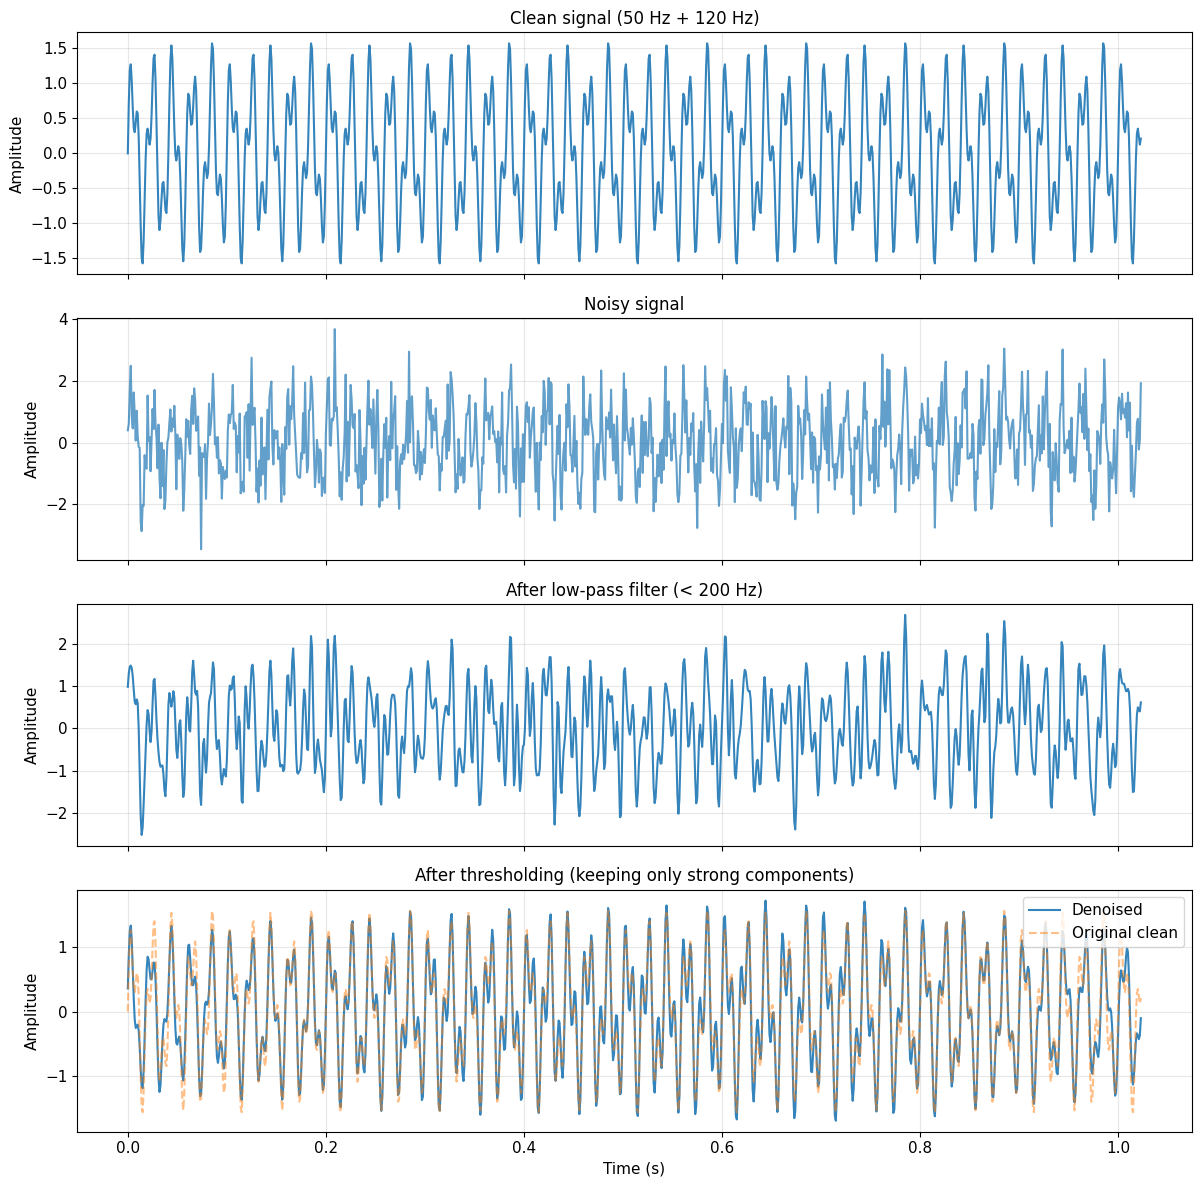

In [13]:
np.random.seed(42)

N_real = 1024
fs_real = 1000  # 1000 Hz sampling rate
t_real = np.arange(N_real) / fs_real
freq_axis = np.fft.fftfreq(N_real, d=1/fs_real)

# Clean signal: two frequencies
clean = 1.0 * np.sin(2 * np.pi * 50 * t_real) + 0.6 * np.sin(2 * np.pi * 120 * t_real)

# Add noise
noisy = clean + 0.8 * np.random.randn(N_real)

# FFT
X_noisy = np.fft.fft(noisy)

# Create a brick-wall filter: keep only frequencies below 200 Hz
filter_mask = np.abs(freq_axis) < 200
X_filtered = X_noisy * filter_mask

# Additionally, zero out small-magnitude components (denoise)
threshold = 0.15 * np.max(np.abs(X_filtered))
X_denoised = np.where(np.abs(X_filtered) > threshold, X_filtered, 0)

# Reconstruct
filtered = np.real(np.fft.ifft(X_filtered))
denoised = np.real(np.fft.ifft(X_denoised))

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(t_real, clean, alpha=0.9)
axes[0].set_title('Clean signal (50 Hz + 120 Hz)', fontsize=12)
axes[0].set_ylabel('Amplitude')

axes[1].plot(t_real, noisy, alpha=0.7)
axes[1].set_title('Noisy signal', fontsize=12)
axes[1].set_ylabel('Amplitude')

axes[2].plot(t_real, filtered, alpha=0.9)
axes[2].set_title('After low-pass filter (< 200 Hz)', fontsize=12)
axes[2].set_ylabel('Amplitude')

axes[3].plot(t_real, denoised, alpha=0.9, label='Denoised')
axes[3].plot(t_real, clean, '--', alpha=0.5, label='Original clean')
axes[3].set_title('After thresholding (keeping only strong components)', fontsize=12)
axes[3].set_ylabel('Amplitude')
axes[3].set_xlabel('Time (s)')
axes[3].legend()

plt.tight_layout()
plt.show()

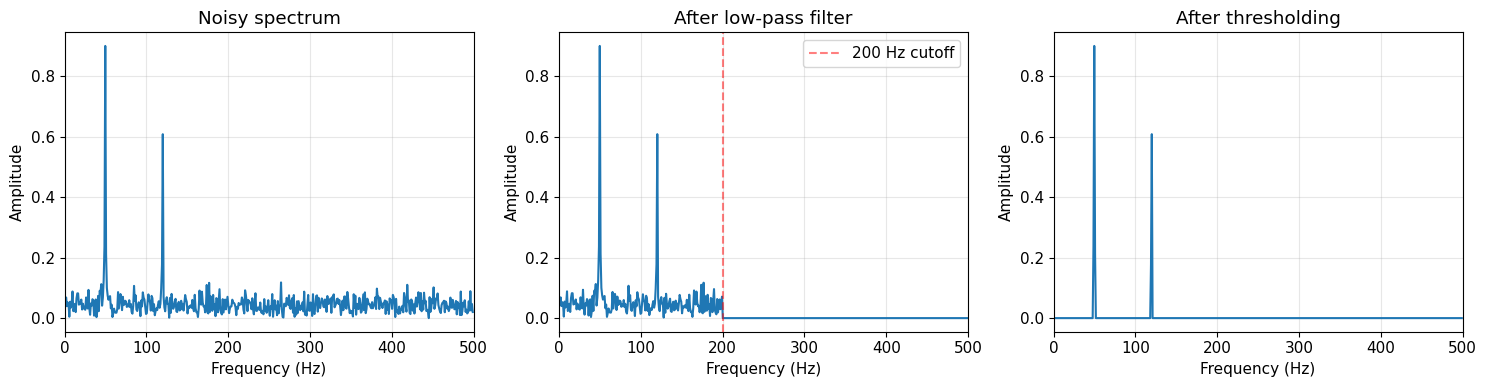

In [14]:
# Show the frequency domain view
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pos = freq_axis[:N_real//2]

axes[0].plot(pos, 2/N_real * np.abs(X_noisy[:N_real//2]))
axes[0].set_title('Noisy spectrum')

axes[1].plot(pos, 2/N_real * np.abs(X_filtered[:N_real//2]))
axes[1].axvline(200, color='red', linestyle='--', alpha=0.5, label='200 Hz cutoff')
axes[1].set_title('After low-pass filter')
axes[1].legend()

axes[2].plot(pos, 2/N_real * np.abs(X_denoised[:N_real//2]))
axes[2].set_title('After thresholding')

for ax in axes:
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, 500)

plt.tight_layout()
plt.show()

## 9. The DFT Matrix: A Linear Algebra Perspective

The DFT can be written as a matrix-vector multiplication $\mathbf{X} = \mathbf{W} \mathbf{x}$, where:

$$W_{kn} = e^{-i 2\pi k n / N}$$

Each row of $\mathbf{W}$ is a complex sinusoid at a different frequency. The DFT is simply projecting the signal onto these basis vectors.

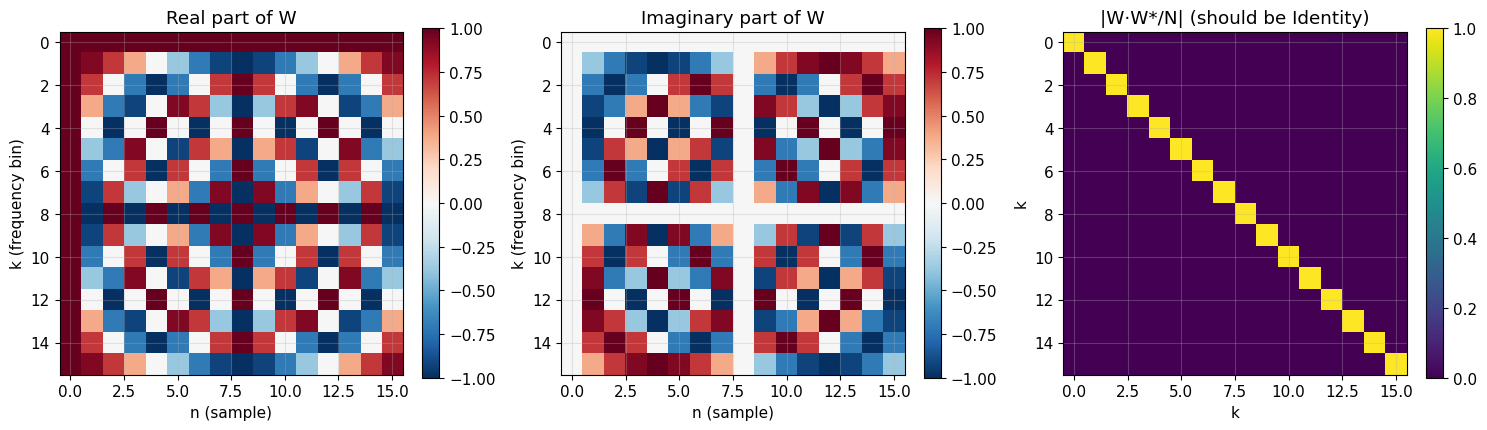

W is unitary (up to scale): max off-diagonal = 1.87e-15


In [15]:
N_mat = 16  # small N so we can visualize the matrix
n = np.arange(N_mat)
k = np.arange(N_mat)

# Build the DFT matrix
W = np.exp(-2j * np.pi * np.outer(k, n) / N_mat)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].imshow(W.real, cmap='RdBu_r', aspect='equal', vmin=-1, vmax=1)
axes[0].set_title('Real part of W')
axes[0].set_xlabel('n (sample)')
axes[0].set_ylabel('k (frequency bin)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(W.imag, cmap='RdBu_r', aspect='equal', vmin=-1, vmax=1)
axes[1].set_title('Imaginary part of W')
axes[1].set_xlabel('n (sample)')
axes[1].set_ylabel('k (frequency bin)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Verify orthogonality: W @ W* / N should be identity
product = W @ W.conj().T / N_mat
im2 = axes[2].imshow(np.abs(product), cmap='viridis', aspect='equal')
axes[2].set_title('|W·W*/N| (should be Identity)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('k')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"W is unitary (up to scale): max off-diagonal = {np.max(np.abs(product - np.eye(N_mat))):.2e}")

## 10. From DFT to the Continuous Fourier Transform

The **continuous Fourier transform** (CFT) is defined as:

$$\hat{x}(f) = \int_{-\infty}^{\infty} x(t)\, e^{-i 2\pi f t}\, dt$$

The DFT approximates this integral via a Riemann sum. If we sample $x(t)$ at interval $\Delta t$ for $N$ points, the connection is:

$$\hat{x}(f_k) \approx \Delta t \cdot X[k], \qquad f_k = \frac{k}{N \Delta t}$$

We can verify this by choosing signals with **known analytical transforms** and comparing the scaled DFT to the closed-form result.

| Signal | $x(t)$ | Analytical $\hat{x}(f)$ |
|---|---|---|
| Gaussian | $e^{-\alpha t^2}$ | $\sqrt{\pi/\alpha}\; e^{-\pi^2 f^2/\alpha}$ |
| Rectangular pulse | $1$ if $\lvert t\rvert < T/2$, else $0$ | $T\,\mathrm{sinc}(fT)$ |
| Exponential decay | $e^{-\alpha\lvert t\rvert}$ | $\frac{2\alpha}{\alpha^2 + (2\pi f)^2}$ |

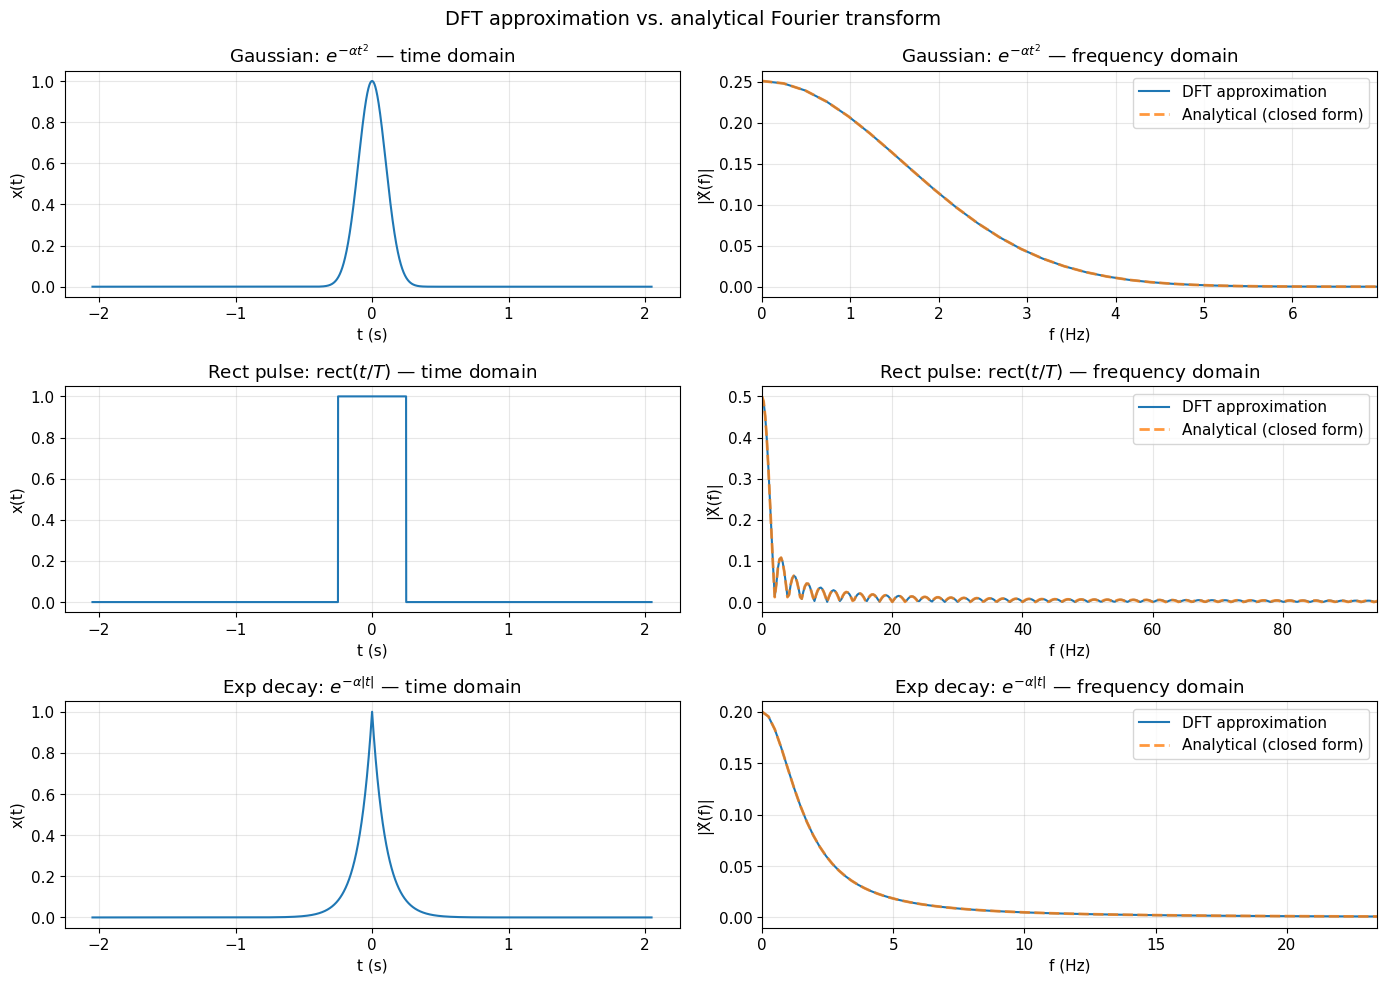

In [16]:
# --- Analytical vs DFT comparison for three classic signals ---

N_a = 4096
dt = 0.001  # sampling interval (1 ms)
t_a = (np.arange(N_a) - N_a // 2) * dt  # centered time axis: -2.048s to +2.047s

# Frequency axis for the DFT (only positive half)
freqs_a = np.fft.fftfreq(N_a, d=dt)
pos_mask = freqs_a >= 0
f_pos = freqs_a[pos_mask]

# --- 1. Gaussian: x(t) = exp(-α t²) ---
alpha = 50.0
x_gauss = np.exp(-alpha * t_a**2)
# Analytical: sqrt(π/α) * exp(-π² f² / α)
X_gauss_analytical = np.sqrt(np.pi / alpha) * np.exp(-np.pi**2 * f_pos**2 / alpha)

# --- 2. Rectangular pulse: x(t) = 1 for |t| < T/2 ---
T_rect = 0.5  # pulse width
x_rect = np.where(np.abs(t_a) < T_rect / 2, 1.0, 0.0)
# Analytical: T * sinc(f * T)  (np.sinc includes the π)
X_rect_analytical = T_rect * np.sinc(f_pos * T_rect)

# --- 3. Exponential decay: x(t) = exp(-α|t|) ---
alpha_exp = 10.0
x_exp = np.exp(-alpha_exp * np.abs(t_a))
# Analytical: 2α / (α² + (2πf)²)
X_exp_analytical = 2 * alpha_exp / (alpha_exp**2 + (2 * np.pi * f_pos)**2)

# Compute DFT approximations: X_hat(f) ≈ Δt * DFT[x]
# We use fftshift because our time axis is centered
signals = [
    ("Gaussian: $e^{-\\alpha t^2}$", x_gauss, X_gauss_analytical),
    ("Rect pulse: $\\mathrm{rect}(t/T)$", x_rect, X_rect_analytical),
    ("Exp decay: $e^{-\\alpha|t|}$", x_exp, X_exp_analytical),
]

fig, axes = plt.subplots(len(signals), 2, figsize=(14, 10))

for row, (name, x_t, X_analytical) in enumerate(signals):
    # DFT approximation to CFT: multiply by dt, shift to account for centered time
    X_dft = np.fft.fft(np.fft.ifftshift(x_t)) * dt  # ifftshift undoes the centering
    X_dft_pos = np.abs(X_dft[pos_mask])

    # Time domain
    axes[row, 0].plot(t_a, x_t, linewidth=1.5)
    axes[row, 0].set_title(f'{name} — time domain')
    axes[row, 0].set_xlabel('t (s)')
    axes[row, 0].set_ylabel('x(t)')

    # Frequency domain: DFT vs analytical
    axes[row, 1].plot(f_pos, X_dft_pos, label='DFT approximation', linewidth=1.5)
    axes[row, 1].plot(f_pos, np.abs(X_analytical), '--', label='Analytical (closed form)',
                      linewidth=2, alpha=0.8)
    axes[row, 1].set_title(f'{name} — frequency domain')
    axes[row, 1].set_xlabel('f (Hz)')
    axes[row, 1].set_ylabel('|X̂(f)|')
    axes[row, 1].legend()

    # Zoom to where the action is
    significant = np.abs(X_analytical) > 0.01 * np.max(np.abs(X_analytical))
    if np.any(significant):
        f_max = f_pos[significant][-1] * 1.5
        axes[row, 1].set_xlim(0, min(f_max, f_pos[-1]))

fig.suptitle('DFT approximation vs. analytical Fourier transform', fontsize=14)
plt.tight_layout()
plt.show()

The DFT (solid lines) overlaps almost perfectly with the closed-form analytical solutions (dashed lines). Notable observations:

- **Gaussian → Gaussian**: A Gaussian in time transforms to a Gaussian in frequency. The wider the time-domain Gaussian (smaller $\alpha$), the narrower it is in frequency — a manifestation of the **uncertainty principle**.
- **Rectangular pulse → sinc**: The sharp edges in time produce the slowly-decaying sinc oscillations in frequency. Sharp features need many frequencies to represent.
- **Exponential decay → Lorentzian**: The smooth-but-peaked exponential produces a smooth, bell-shaped Lorentzian spectrum.

### Convergence: DFT → CFT as $N$ grows

The DFT approximation improves as we increase the number of samples $N$ (finer $\Delta t$, longer observation window). Let's watch the Gaussian case converge.

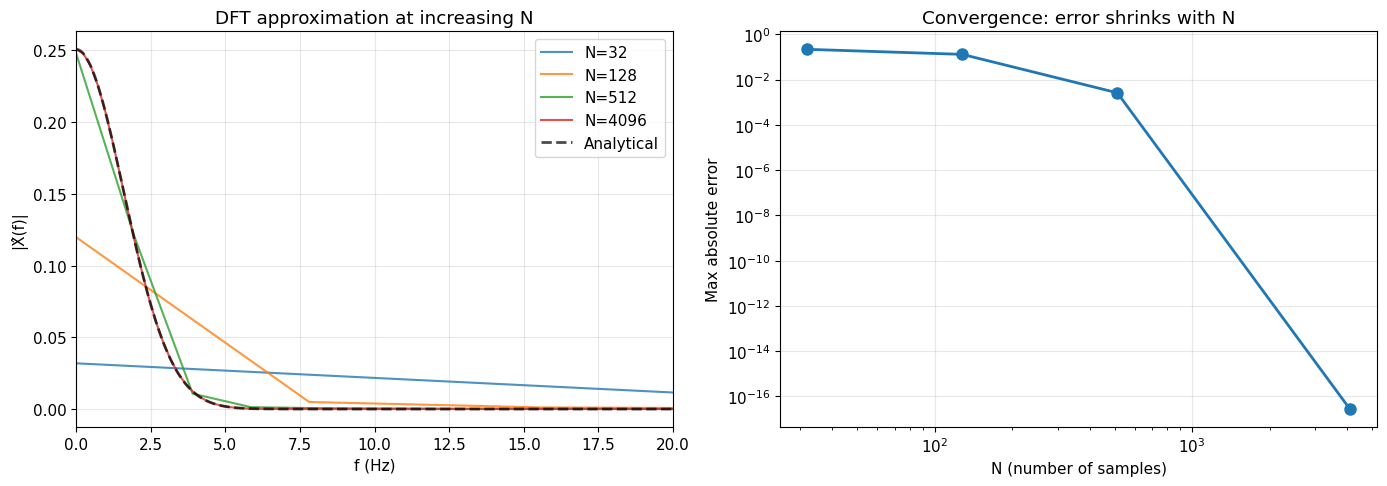

  N =    32  →  max error = 2.19e-01
  N =   128  →  max error = 1.31e-01
  N =   512  →  max error = 2.62e-03
  N =  4096  →  max error = 2.78e-17


In [17]:
# Convergence of DFT → analytical CFT for the Gaussian as N increases

alpha_conv = 50.0
sample_counts = [32, 128, 512, 4096]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

errors = []

for N_c in sample_counts:
    dt_c = 0.001
    t_c = (np.arange(N_c) - N_c // 2) * dt_c
    x_c = np.exp(-alpha_conv * t_c**2)

    freqs_c = np.fft.fftfreq(N_c, d=dt_c)
    pos_c = freqs_c >= 0
    f_c = freqs_c[pos_c]

    # DFT approximation
    X_dft_c = np.abs(np.fft.fft(np.fft.ifftshift(x_c)) * dt_c)[pos_c]

    # Analytical
    X_anal_c = np.sqrt(np.pi / alpha_conv) * np.exp(-np.pi**2 * f_c**2 / alpha_conv)

    # Max absolute error (over shared frequency range)
    err = np.max(np.abs(X_dft_c - X_anal_c))
    errors.append(err)

    axes[0].plot(f_c, X_dft_c, label=f'N={N_c}', alpha=0.8)

# Overlay analytical
f_dense = np.linspace(0, 20, 1000)
X_anal_dense = np.sqrt(np.pi / alpha_conv) * np.exp(-np.pi**2 * f_dense**2 / alpha_conv)
axes[0].plot(f_dense, X_anal_dense, 'k--', linewidth=2, label='Analytical', alpha=0.7)
axes[0].set_xlim(0, 20)
axes[0].set_title('DFT approximation at increasing N')
axes[0].set_xlabel('f (Hz)')
axes[0].set_ylabel('|X̂(f)|')
axes[0].legend()

axes[1].loglog(sample_counts, errors, 'o-', markersize=8, linewidth=2)
axes[1].set_xlabel('N (number of samples)')
axes[1].set_ylabel('Max absolute error')
axes[1].set_title('Convergence: error shrinks with N')

plt.tight_layout()
plt.show()

for N_c, err in zip(sample_counts, errors):
    print(f"  N = {N_c:5d}  →  max error = {err:.2e}")

Each row of the DFT matrix is a sampled complex sinusoid. Row 0 is DC (constant), row 1 completes one cycle, row 2 completes two cycles, etc. The rows are orthogonal, which is why the transform is invertible and information-preserving.

## Summary

| Concept | Key takeaway |
|---|---|
| **Core idea** | Correlate signal with complex exponentials at each frequency |
| **DFT formula** | $X[k] = \sum_n x[n] \, e^{-i2\pi kn/N}$ |
| **Magnitude** | How much of each frequency is present |
| **Phase** | Where each frequency component starts |
| **Linearity** | Transform of sum = sum of transforms |
| **Time shift** | Changes phase, not magnitude |
| **Parseval** | Energy is conserved across domains |
| **Convolution** | Time-domain convolution = frequency-domain multiplication |
| **Windowing** | Reduces spectral leakage for non-periodic signals |
| **DFT matrix** | The transform is a projection onto orthogonal sinusoidal basis vectors |
| **DFT ↔ CFT** | $\hat{x}(f_k) \approx \Delta t \cdot X[k]$ — the DFT is a Riemann-sum approximation to the continuous integral, converging as $N \to \infty$ |